In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw5.ipynb")

# CPSC 330 - Applied Machine Learning 

## Homework 5: Putting it all together 
### Associated lectures: All material till lecture 13 

<div class="alert-warning">
    
## Instructions  
rubric={points}

You will earn points for following these instructions and successfully submitting your work on Gradescope.  

### Before you start  

- Please **read carefully
[Use of Generative AI policy](https://ubc-cs.github.io/cpsc330-2025W2/syllabus#use-of-generative-ai-in-the-course)** before starting the homework assignment. 
  
- Review the [CPSC 330 homework instructions](https://ubc-cs.github.io/cpsc330-2025W2/docs/homework-instructions) for detailed guidance on completing and submitting assignments. 

### Group work instructions

**You may work with a partner on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2.
  
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).
- If you would like to use late tokens for the homework, all group members must have the necessary late tokens available. Please note that the late tokens will be counted for all members of the group.   
### Before submitting  

- **Run all cells** (▶▶ button) to ensure the notebook executes cleanly from top to bottom.

  - Execution counts must start at **1** and be sequential.
    
  - Notebooks with missing outputs or errors may lose marks.

- **Do not upload or push data files** used in this lab to GitHub or Gradescope. (A `.gitignore` is provided to prevent this.)  


### Submitting on Gradescope  

- Upload **only** your `.ipynb` file (with outputs shown) and any required output files. Do **not** submit extra files.
  
- If needed, refer to the [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/).  
- If your notebook is too large to render, also upload a **Web PDF** or **HTML** version.  
  - You can create one using **File $\rightarrow$ Save and Export Notebook As**.  
  - If you get an error when creating a PDF, try running the following commands in your lab directory:  

    ```bash
    conda install -c conda-forge nbconvert-playwright
    jupyter nbconvert --to webpdf lab1.ipynb
    ```  

  - Ensure all outputs are visible in your PDF or HTML file; TAs cannot grade your work if outputs are missing.

</div>


_Note: Unlike previous assignments, this one is open-ended and project-style. Treat it as an opportunity to explore, experiment, and learn._

<!-- BEGIN QUESTION -->

## Imports

<div class="alert alert-warning">
    
Imports
    
</div>

_Points:_ 0

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, confusion_matrix

<!-- END QUESTION -->

## Introduction

In this homework you will be working on an open-ended mini-project, where you will put all the different things you have learned so far together to solve an interesting problem.

A few notes and tips when you work on this mini-project: 

#### Tips
1. This mini-project is open-ended, and while working on it, there might be some situations where you'll have to use your own judgment and make your own decisions (as you would be doing when you work as a data scientist). Make sure you explain your decisions whenever necessary. 
2. **Do not include everything you ever tried in your submission** -- it's fine just to have your final code. That said, your code should be reproducible and well-documented. For example, if you chose your hyperparameters based on some hyperparameter optimization experiment, you should leave in the code for that experiment so that someone else could re-run it and obtain the same hyperparameters, rather than mysteriously just setting the hyperparameters to some (carefully chosen) values in your code. 
3. If you realize that you are repeating a lot of code try to organize it in functions. Clear presentation of your code, experiments, and results is the key to be successful in this lab. You may use code from lecture notes or previous lab solutions with appropriate attributions. 

#### Assessment
We plan to grade fairly and leniently. We don't have some secret target score that you need to achieve to get a good grade. **You'll be assessed on demonstration of mastery of course topics, clear presentation, and the quality of your analysis and results.** For example, if you just have a bunch of code and no text or figures, that's not good. If you do a bunch of sane things and get a lower accuracy than your friend, don't sweat it.


#### A final note
Finally, this style of this "project" question is different from other assignments. It'll be up to you to decide when you're "done" -- in fact, this is one of the hardest parts of real projects. But please don't spend WAY too much time on this... perhaps "a few hours" (10-14 hours???) is a good guideline for this project . Of course if you're having fun you're welcome to spend as much time as you want! But, if so, try not to do it out of perfectionism or getting the best possible grade. Do it because you're learning and enjoying it. Students from the past cohorts have found such kind of labs useful and fun and I hope you enjoy it as well. 

<br><br>

<!-- BEGIN QUESTION -->

## 1. Pick your problem and explain the prediction problem
<hr>
rubric={points:3}

In this mini project, you have the option to choose on which dataset you will be working on. The tasks you will need to carry on will be similar, independently of your choice.

### Option 1
You can choose to work on a classification problem of predicting whether a credit card client will default or not. 
For this problem, you will use [Default of Credit Card Clients Dataset](https://www.kaggle.com/uciml/default-of-credit-card-clients-dataset). In this data set, there are 30,000 examples and 24 features, and the goal is to estimate whether a person will default (fail to pay) their credit card bills; this column is labeled "default.payment.next.month" in the data. The rest of the columns can be used as features. You may take some ideas and compare your results with [the associated research paper](https://www.sciencedirect.com/science/article/pii/S0957417407006719), which is available through [the UBC library](https://www.library.ubc.ca/). 


### Option 2
You can choose to work on a regression problem using a [dataset](https://www.kaggle.com/dgomonov/new-york-city-airbnb-open-data) of New York City Airbnb listings from 2019. As usual, you'll need to start by downloading the dataset, then you will try to predict `reviews_per_month`, as a proxy for the popularity of the listing. Airbnb could use this sort of model to predict how popular future listings might be before they are posted, perhaps to help guide hosts create more appealing listings. In reality they might instead use something like vacancy rate or average rating as their target, but we do not have that available here.

> Note there is an updated version of this dataset with more features available [here](http://insideairbnb.com/). The features were are using in `listings.csv.gz` for the New York city datasets. You will also see some other files like `reviews.csv.gz`. For your own interest you may want to explore the expanded dataset and try your analysis there. However, please submit your results on the dataset obtained from Kaggle.


<div class="alert alert-info">
    
**Your tasks:**

1. Review the available datasets and choose the one you find most interesting. It may help to read through the dataset documentation on Kaggle before deciding.
2. Once you've selected a dataset, take time to understand the problem it represents and the meaning of each feature. Use the Kaggle documentation to guide you.
3. Download the dataset and load it into a pandas DataFrame.
4. Write a few sentences summarizing your initial thoughts about the problem and the dataset.
   
</div>

<div class="alert alert-warning">
    
Solution_1
    
</div>

_Points:_ 3

This project uses the Default of Credit Card Clients (Taiwan) dataset, which contains information about 30,000 credit card clients from April 2005 to September 2005. The dataset includes demographics (e.g., sex, education, marital status, age), credit information (e.g., credit limit), and multiple months of repayment status, bill statement amounts, and payment amounts. The prediction target is whether a client will default next month (default.payment.next.month, where 1 = default and 0 = not default). This is a binary classification task. This seems similar to some of the problems we have done in class, so it seems best to start with a DummyClassifier as a baseline and then improve, as well as to evaluate with metrics like F1 score and confusion matrix due to the liklihood of class imbalance; it seems possible that default payment would be less frequent than non-default.

In [3]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2. Data splitting
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. Split the data into train (70%) and test (30%) portions with `random_state=123`.

> If your computer cannot handle training on 70% training data, make the test split bigger.

</div>

<div class="alert alert-warning">
    
Solution_2
    
</div>

_Points:_ 2

In [4]:
df = pd.read_csv("data/UCI_Credit_Card.csv")

target = "default.payment.next.month"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=123,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

X_train shape: (21000, 24)
X_test shape: (9000, 24)

Train class balance:
 default.payment.next.month
0    0.77881
1    0.22119
Name: proportion, dtype: float64

Test class balance:
 default.payment.next.month
0    0.778778
1    0.221222
Name: proportion, dtype: float64


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 3. EDA
<hr>
rubric={points:10}

<div class="alert alert-info">

**Your tasks:**

1. **Perform exploratory data analysis (EDA)**: Conduct an initial exploration of the training set to better understand its characteristics.

2. **Summarize and visualize the data**: Include at least **two summary statistics** and **two visualizations** that you find informative. For each, write **one sentence** explaining what insight it provides.

3. **Record your observations**: Summarize your **initial observations** about the dataset based on your EDA.

4. **Select evaluation metrics**: Choose one or more **appropriate metrics** for assessing model performance and briefly justify your choice.

</div>

<div class="alert alert-warning">
    
Solution_3
    
</div>

_Points:_ 10

Summary statistic 1, missing values: A missing-value check on the training set shows 0 missing values in the displayed columns, suggesting that the dataset can be modeled without imputation.

Summary statistic 2, descriptive statistics: The summary statistics show that variables have very different scales (e.g. LIMIT_BAL ranges up to 1,000,000 while PAY_* contains small integers), which indicates that scaling may be important for some models.

Visualization 1 (class bias): The bar plot confirms a class imbalance in the training data (≈ 77.9% non-default vs ≈ 22.1% default), meaning that accuracy alone could be misleading.

Visualization 2 (default rate vs repayment status PAY_0): The plot shows that the default rate increases substantially as PAY_0 increases, suggesting that recent delinquency/repayment status is strongly predictive of default risk.

Initial observations: Overall, the dataset appears clean (no missing values) but has an imbalanced target. Repayment-status variables (PAY_*) show a strong relationship with default, while many numeric features vary widely in scale, which may benefit from preprocessing (e.g., scaling) and careful model selection.

Evaluation metrics: The evaluation metrics will be the F1-score and confusion matrix. Because the default class is the minority, accuracy alone can be misleading. The confusion matrix provides a clear breakdown of false positives and false negatives, and the F1-score summarizes performance by balancing precision and recall for detecting defaults.

In [5]:
# use the train split from Solution_2
Xtr = X_train.copy()
ytr = y_train.copy()

# drop ID if it exists
if "ID" in Xtr.columns:
    Xtr = Xtr.drop(columns=["ID"])

df_train = Xtr.copy()
df_train["default"] = ytr
df_train.shape

(21000, 24)

In [6]:
# Missing values check
missing = df_train.isna().sum().sort_values(ascending=False)
missing.head(10)

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
dtype: int64

In [7]:
# Summary stats for numeric columns
df_train.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,21000.0,167627.318095,129860.863421,10000.0,50000.0,140000.0,240000.0,1000000.0
SEX,21000.0,1.602476,0.489398,1.0,1.0,2.0,2.0,2.0
EDUCATION,21000.0,1.855762,0.787604,0.0,1.0,2.0,2.0,6.0
MARRIAGE,21000.0,1.551048,0.523430,0.0,1.0,2.0,2.0,3.0
AGE,21000.0,35.488476,9.224177,21.0,28.0,34.0,41.0,79.0
PAY_0,21000.0,-0.017429,1.125270,-2.0,-1.0,0.0,0.0,8.0
PAY_2,21000.0,-0.127810,1.199651,-2.0,-1.0,0.0,0.0,7.0
PAY_3,21000.0,-0.159238,1.203743,-2.0,-1.0,0.0,0.0,8.0
PAY_4,21000.0,-0.216095,1.174019,-2.0,-1.0,0.0,0.0,8.0
PAY_5,21000.0,-0.259524,1.138940,-2.0,-1.0,0.0,0.0,8.0


In [8]:
ytr.value_counts(), ytr.value_counts(normalize=True)

(default.payment.next.month
 0    16355
 1     4645
 Name: count, dtype: int64,
 default.payment.next.month
 0    0.77881
 1    0.22119
 Name: proportion, dtype: float64)

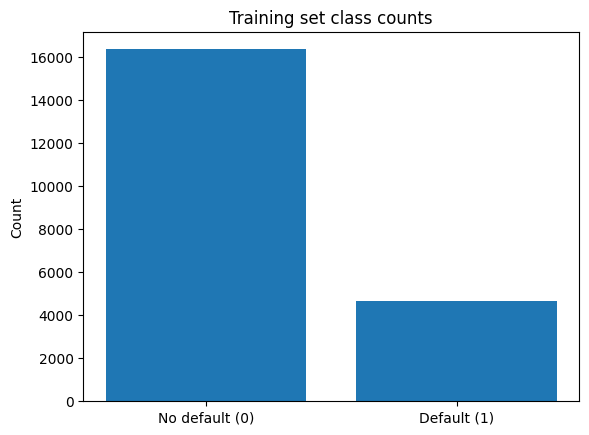

In [9]:
counts = ytr.value_counts().sort_index()
plt.figure()
plt.bar(["No default (0)", "Default (1)"], counts.values)
plt.title("Training set class counts")
plt.ylabel("Count")
plt.show()

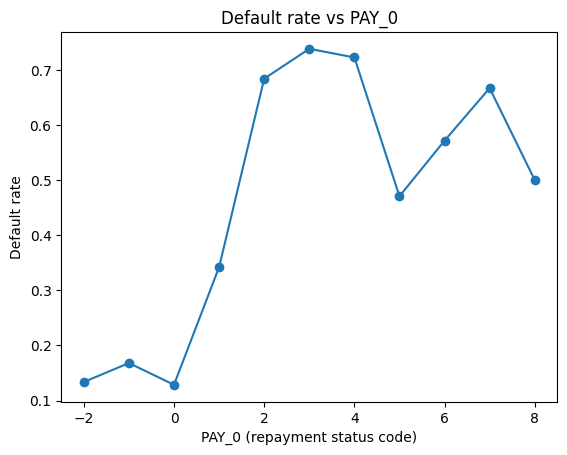

In [10]:
pay_cols = [c for c in df_train.columns if c.startswith("PAY_")]
pay0 = "PAY_0" if "PAY_0" in df_train.columns else pay_cols[0]  # fallback

default_rate_by_pay = df_train.groupby(pay0)["default"].mean().sort_index()

plt.figure()
plt.plot(default_rate_by_pay.index, default_rate_by_pay.values, marker="o")
plt.title(f"Default rate vs {pay0}")
plt.xlabel(f"{pay0} (repayment status code)")
plt.ylabel("Default rate")
plt.show()

In [11]:
...

Ellipsis

In [12]:
...

Ellipsis

In [13]:
...

Ellipsis

In [14]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 4. Feature engineering
<hr>
rubric={points:1}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature engineering**: Create new features that are relevant to the problem and use this updated feature set in the following exercises. You may need to iterate between **feature engineering** and **preprocessing** to refine your features and improve model performance.
   
</div>

<div class="alert alert-warning">
    
Solution_4
    
</div>

_Points:_ 1

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 5. Preprocessing and transformations
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Identify feature types**: Determine the different types of features in your dataset (e.g., numerical, categorical, ordinal, text) and specify the transformations you would apply to each type.

2. **Define a column transformer (if needed)**: Implement a `ColumnTransformer` to apply the appropriate preprocessing steps to each feature type.
 
</div>

<div class="alert alert-warning">
    
Solution_5
    
</div>

_Points:_ 10

In [15]:
def add_engineered_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()

    # Drop ID if present
    if "ID" in X.columns:
        X = X.drop(columns=["ID"])

    pay_cols = [c for c in X.columns if c.startswith("PAY_")]
    bill_cols = [c for c in X.columns if c.startswith("BILL_AMT")]
    payamt_cols = [c for c in X.columns if c.startswith("PAY_AMT")]

    # repayment summary features 
    if len(pay_cols) > 0:
        X["pay_mean"] = X[pay_cols].mean(axis=1)
        X["pay_max"] = X[pay_cols].max(axis=1)
        X["any_late_payment"] = (X[pay_cols] > 0).any(axis=1).astype(int)

    # bill/payment summary features 
    if len(bill_cols) > 0:
        X["bill_total"] = X[bill_cols].sum(axis=1)
        X["bill_mean"] = X[bill_cols].mean(axis=1)

    if len(payamt_cols) > 0:
        X["pay_total"] = X[payamt_cols].sum(axis=1)
        X["pay_mean_amt"] = X[payamt_cols].mean(axis=1)

    # payment coverage ratio: how much paid relative to billed 
    if ("bill_total" in X.columns) and ("pay_total" in X.columns):
        X["pay_to_bill_ratio"] = X["pay_total"] / (X["bill_total"] + 1e-6)

    # utilization proxy: most recent bill relative to credit limit 
    if "LIMIT_BAL" in X.columns and "BILL_AMT1" in X.columns:
        X["utilization_1"] = X["BILL_AMT1"] / (X["LIMIT_BAL"] + 1e-6)

    return X

In [16]:
X_train_fe = add_engineered_features(X_train)
X_test_fe  = add_engineered_features(X_test)

X_train_fe.shape, X_test_fe.shape

((21000, 32), (9000, 32))

In [17]:
Xtr = X_train_fe.copy()
Xte = X_test_fe.copy()

categorical_features = [c for c in ["SEX", "EDUCATION", "MARRIAGE"] if c in Xtr.columns]
numeric_features = [c for c in Xtr.columns if c not in categorical_features]

In [18]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", StandardScaler(), numeric_features),
    ],
    remainder="drop"
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [19]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 6. Baseline model
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Establish a baseline**: Use one of `scikit-learn`’s baseline models (e.g., `DummyClassifier` or `DummyRegressor`, depending on your task) and report the results. This will serve as a reference point for evaluating the performance of your more advanced models.

</div>

<div class="alert alert-warning">
    
Solution_6
    
</div>

_Points:_ 2

In [20]:
# Baseline: always predict the most frequent class
dummy = DummyClassifier(strategy="most_frequent", random_state=123)
dummy.fit(X_train_fe, y_train)

y_pred = dummy.predict(X_test_fe)

In [21]:
print("DummyClassifier (most_frequent) Test F1:", f1_score(y_test, y_pred))

DummyClassifier (most_frequent) Test F1: 0.0


In [22]:
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

Confusion matrix:
 [[7009    0]
 [1991    0]]


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 7. Linear models 
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Train a linear model**: Use a linear model as your first real attempt at solving the problem.

2. **Tune hyperparameters**: Perform hyperparameter tuning to explore different values of the model's complexity parameter. 

3. **Evaluate with cross-validation**: Report the cross-validation scores along with their standard deviation.

4. **Summarize findings**: Summarize your results, highlighting key observations from your experiments.

</div>

<div class="alert alert-warning">
    
Solution_7
    
</div>

_Points:_ 10

A Logistic Regression model was trained as a linear baseline classifier using a preprocessing pipeline (one-hot encoding for categorical features and standard scaling for numeric features). Hyperparameter tuning was performed over the regularization parameter C using 5-fold stratified cross-validation with F1-score as the evaluation metric. The best-performing value was C = 10, achieving a mean CV F1-score of 0.3655 ± 0.0066. On the held-out test set, the tuned model achieved an F1-score of 0.3442, substantially improving over the DummyClassifier baseline (F1 = 0). 

The confusion matrix indicates the model identifies some defaults (TP = 454) but still misses many (FN = 1537), suggesting recall for the default class remains a key area to improve.

In [23]:
pipe_lr = Pipeline([
    ("preprocess", preprocessor),   # from Solution_5
    ("clf", LogisticRegression(max_iter=5000, solver="liblinear"))
])

In [24]:
param_grid = {
    "clf__C": [0.01, 0.1, 1, 10, 100]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

grid = GridSearchCV(
    pipe_lr,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

grid.fit(X_train_fe, y_train)

print("Best params:", grid.best_params_)
print("Best CV F1:", grid.best_score_)

Best params: {'clf__C': 10}
Best CV F1: 0.36554020908580603


In [25]:
results = pd.DataFrame(grid.cv_results_)

summary = results[["param_clf__C", "mean_test_score", "std_test_score", "mean_train_score", "std_train_score"]]
summary = summary.sort_values(by="mean_test_score", ascending=False)

summary

,param_clf__C,mean_test_score,std_test_score,mean_train_score,std_train_score
3,10.00,0.365540,0.006609,0.365216,0.007719
4,100.00,0.365480,0.006505,0.365331,0.007777
2,1.00,0.364471,0.006465,0.364463,0.007323
1,0.10,0.361210,0.007253,0.361615,0.006483
0,0.01,0.350810,0.009989,0.353062,0.006062


In [26]:
best_lr = grid.best_estimator_
y_pred_lr = best_lr.predict(X_test_fe)

print("Test F1:", f1_score(y_test, y_pred_lr))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_lr))

Test F1: 0.34420015163002277
Confusion matrix:
 [[6816  193]
 [1537  454]]


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 8. Different models
<hr>
rubric={points:12}

<div class="alert alert-info">
    
**Your tasks:**

1. **Experiment with additional models**: Train at least **three models** other than a linear model. Ensure that **at least one** of these models is a **tree-based ensemble model** (e.g., Random Forest, Gradient Boosting, or XGBoost).

2. **Compare and interpret results**: Summarize your findings in terms of **overfitting/underfitting** behavior and **fit/score times** for each model. Reflect on your results. Were you able to **outperform the linear model**?

</div>

<div class="alert alert-warning">
    
Solution_8
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [27]:
...

Ellipsis

In [28]:
...

Ellipsis

In [29]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 9. Feature selection 
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

1. **Perform feature selection**: Attempt to select relevant features using methods such as `RFECV` or forward selection.

2. **Evaluate the impact** Compare the model performance before and after feature selection. Do the results improve with feature selection?

3. **Summarize findings** Summarize your observations and decide whether to **keep feature selection** in your pipeline.  If it improves results, retain it for the next exercises; otherwise, you may choose to omit it.
</div>

<div class="alert alert-warning">
    
Solution_9
    
</div>

_Points:_ 2

_Type your answer here, replacing this text._

In [30]:
...

Ellipsis

In [31]:
...

Ellipsis

In [32]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 10. Hyperparameter optimization
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Optimize hyperparameters**: Attempt to optimize hyperparameters for the models you have tried so far. In at least **one case**, tune **multiple hyperparameters** for a single model.

2. **Use suitable optimization methods**: You may use any of the following approaches for hyperparameter optimization:
   - [`GridSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)  
   - [`RandomizedSearchCV`](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html)  
   - [Bayesian optimization with scikit-optimize](https://github.com/scikit-optimize/scikit-optimize)

3. **Summarize your results**: Report and compare the optimized results across models. Discuss whether hyperparameter optimization led to performance improvements.

</div>

<div class="alert alert-warning">
    
Solution_10
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [33]:
...

Ellipsis

In [34]:
...

Ellipsis

In [35]:
...

Ellipsis

In [36]:
...

Ellipsis

In [37]:
...

Ellipsis

In [38]:
...

Ellipsis

In [39]:
...

Ellipsis

In [40]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 11. Interpretation and feature importances
<hr>
rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Interpret model feature importance**: Use one of the interpretation methods discussed in class (e.g., `shap`), or another suitable method of your choice, to examine the most important features of one of your **non-linear models**.

2. **Summarize insights**: Summarize your observations about which features contribute most to the model's predictions and how they influence the outcomes.

   
</div>

<div class="alert alert-warning">
    
Solution_11
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [41]:
...

Ellipsis

In [42]:
...

Ellipsis

In [43]:
...

Ellipsis

In [44]:
...

Ellipsis

In [45]:
...

Ellipsis

In [46]:
...

Ellipsis

In [47]:
...

Ellipsis

In [48]:
...

Ellipsis

In [49]:
...

Ellipsis

In [50]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 12. Results on the test set
<hr>

rubric={points:10}

<div class="alert alert-info">
    
**Your tasks:**

1. **Evaluate on the test set**: Apply your best-performing model to the test data and report the test scores.

2. **Compare and reflect**: Compare the **test scores** with the **validation scores** from previous experiments. Discuss the consistency between them. How much do you **trust your results**? Reflect on whether you might have encountered **optimization bias**.

3. **Explain individual predictions**: Select one or two examples from your test predictions and use an interpretation method (e.g., **SHAP force plots**) to explain these individual predictions.
</div>

<div class="alert alert-warning">
    
Solution_12
    
</div>

_Points:_ 10

_Type your answer here, replacing this text._

In [51]:
...

Ellipsis

In [52]:
...

Ellipsis

In [53]:
...

Ellipsis

In [54]:
...

Ellipsis

In [55]:
...

Ellipsis

In [56]:
...

Ellipsis

In [57]:
...

Ellipsis

In [58]:
...

Ellipsis

In [59]:
...

Ellipsis

In [60]:
...

Ellipsis

In [61]:
...

Ellipsis

In [62]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 13. Summary of results
<hr>
rubric={points:12}

Imagine you are preparing to present the summary of your results to your boss and co-workers.

<div class="alert alert-info">
    
**Your tasks:**

1. **Summarize key results**: Create a clear and concise table highlighting your most important results (e.g., models compared, validation/test scores, key observations).

2. **Write concluding remarks**: Summarize your main takeaways from the project, including what worked well and what did not.

3. **Propose future improvements**: Discuss ideas or approaches you did not try but that could potentially improve **performance** or **interpretability**.

4. **Report final results**: Report your **final test score** and the **metric** you used.

</div>


<div class="alert alert-warning">
    
Solution_13
    
</div>

_Points:_ 12

_Type your answer here, replacing this text._

In [63]:
...

Ellipsis

In [64]:
...

Ellipsis

<!-- END QUESTION -->

<br><br>

<br><br>

<!-- BEGIN QUESTION -->

## 14. Your takeaway
<hr>
rubric={points:2}

<div class="alert alert-info">
    
**Your tasks:**

What is your biggest takeaway from the supervised machine learning material we have learned so far? Please write thoughtful answers.  

</div>

<div class="alert alert-warning">
    
Solution_14
    
</div>

_Points:_ 2

<!-- END QUESTION -->

<br><br>

Before submitting your assignment, please ensure you have followed all the steps in the **Instructions** section at the top.  

### Submission checklist  

- [ ] Restart the kernel and run all cells (▶▶ button)
- [ ] Make sure to push the most up to date version of your homework assignment to your GitHub repository so that we can use it for grading if there are any problems with your submission on Gradescope. 
- [ ] The `.ipynb` file runs without errors and shows all outputs.  
- [ ] Only the `.ipynb` file and required output files are uploaded (no extra files).  
- [ ] If the `.ipynb` file is too large to render on Gradescope, upload a Web PDF and/or HTML version as well.


This was a tricky one but you did it 👏👏!  

![](img/eva-well-done.png)